# Проект: Обучение с учителем: качество модели

**Задача**

Разработать решение для персонализации предложений постоянным клиентам с целью увеличения их покупательской активности.

**План:**
1. Разработайть модель для прогнозирования снижения покупательской активности.
2. Определить и проанализировать сегмент покупателей. Предложить методы повышения их активности, используя данные моделирования, прибыль и исходные данные. Рассмотреть несколько сегментов по желанию.

**Цель:** Создать действенный механизм удержания ценных клиентов через персонализированный подход.

### Загрузка данных

#### Библиотеки

In [1]:
!pip install scikit-learn==1.1.3 matplotlib==3.5.2 phik shap -q 

In [3]:
!pip install phik -q
!pip install shap -q

In [4]:
#Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
# %matplotlib notebook
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import phik
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder,MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

from sklearn.inspection import permutation_importance

#### Датасеты

In [8]:
market_file = pd.read_csv('./market_file.csv')
market_money = pd.read_csv('./market_money.csv')
market_time = pd.read_csv('./market_time.csv')
money = pd.read_csv('./money.csv', sep=';', decimal=',')

all_dfs = [market_file, market_money, market_time, money]
all_dfs_name = ['market_file', 'market_money', 'market_time', 'money']

In [6]:
for df, name_df in zip(all_dfs, all_dfs_name):
    print('Датаcет:', name_df)
    display(df.head())
    print('*'*100)

Датаcет: market_file


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


****************************************************************************************************
Датаcет: market_money


,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


****************************************************************************************************
Датаcет: market_time


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


****************************************************************************************************
Датаcет: money


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


****************************************************************************************************


> Импорт - корректен

In [6]:
for df, name_df in zip(all_dfs, all_dfs_name):
    print('Датаcет:', name_df)
    display(df.info())
    print('*'*100)

Датаcет: market_file
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_се

None

****************************************************************************************************
Датаcет: market_money
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


None

****************************************************************************************************
Датаcет: market_time
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


None

****************************************************************************************************
Датаcет: money
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


None

****************************************************************************************************


>Типы данных - корректны. данные в таблицах соответствуют описанию

> #### Вывод: 
Датасеты загружены корректно. Проверены типы данных и корректность описания.

### Предобработка данных

#### Явная проверка значений Nan

In [7]:
for df, name_df in zip(all_dfs, all_dfs_name):
    print('Датаcет:', name_df)
    display(df.isna().sum())
    print('*'*100)

Датаcет: market_file


id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

****************************************************************************************************
Датаcет: market_money


id         0
Период     0
Выручка    0
dtype: int64

****************************************************************************************************
Датаcет: market_time


id        0
Период    0
минут     0
dtype: int64

****************************************************************************************************
Датаcет: money


id         0
Прибыль    0
dtype: int64

****************************************************************************************************


> Пустых значений нет.

#### Проверка не явных дубликатов

In [8]:
for df, name_df in zip(all_dfs, all_dfs_name):
    print('Датаcет:', name_df)
    for col in df.select_dtypes(['object']).columns:
        print(col,'--', df[col].unique(), end='\n\n')
    print('*'*100)

Датаcет: market_file
Покупательская активность -- ['Снизилась' 'Прежний уровень']

Тип сервиса -- ['премиум' 'стандартт' 'стандарт']

Разрешить сообщать -- ['да' 'нет']

Популярная_категория -- ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']

****************************************************************************************************
Датаcет: market_money
Период -- ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']

****************************************************************************************************
Датаcет: market_time
Период -- ['текущий_месяц' 'предыдцщий_месяц']

****************************************************************************************************
Датаcет: money
****************************************************************************************************


**Проблемы:**
* 'стандартт', 'стандарт' - Дубликат. В market_file;
* 'предыдцщий_месяц'- Ошибка в слове. В market_time.

>**Заменим** 'стандартт' на 'стандарт' и 'предыдцщий_месяц' на 'предыдущий_месяц'

In [9]:
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц')

>**Проверка**

In [10]:
for df, name_df in zip(all_dfs, all_dfs_name):
    print('Датаcет:', name_df)
    for col in df.select_dtypes(['object']).columns:
        print(col,'--', df[col].unique(), end='\n\n')
    print('*'*100)

Датаcет: market_file
Покупательская активность -- ['Снизилась' 'Прежний уровень']

Тип сервиса -- ['премиум' 'стандарт']

Разрешить сообщать -- ['да' 'нет']

Популярная_категория -- ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']

****************************************************************************************************
Датаcет: market_money
Период -- ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']

****************************************************************************************************
Датаcет: market_time
Период -- ['текущий_месяц' 'предыдущий_месяц']

****************************************************************************************************
Датаcет: money
****************************************************************************************************


> Корректно.

#### Явные дубликаты

In [11]:
for df, name_df in zip(all_dfs, all_dfs_name):
    print('Датаcет:', name_df)
    print('\nКоличество явных дубликатов в датасете:', df.duplicated().sum())
    print('*'*100)

Датаcет: market_file

Количество явных дубликатов в датасете: 0
****************************************************************************************************
Датаcет: market_money

Количество явных дубликатов в датасете: 0
****************************************************************************************************
Датаcет: market_time

Количество явных дубликатов в датасете: 0
****************************************************************************************************
Датаcет: money

Количество явных дубликатов в датасете: 0
****************************************************************************************************


> Явных дупликатов - нет.
> #### Вывод:
Проверено наличие пустых значений в датасетах. 

### Исследовательский анализ данных

In [12]:
#Просмотр статистики для указанной колонки и постройка графика
def check_stat_and_graf(df, col, bins=50):
    if df[col].dtypes in ['int64', 'float64']:
        plt.figure(figsize=(10, 8))
        df[col].plot(kind='hist', bins=bins)
        
        plt.title(f'Гистограмма: {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.show()
        
        print(df[col].describe())
    else:
        plt.figure(figsize=(9, 8))
        df[col].value_counts().plot(kind='bar')
        
        plt.title(f'Столбчатое распределение: {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.tight_layout(pad=3.0)
        plt.show()
        
        print(df[col].value_counts())

In [13]:
market_file_col = market_file.columns
market_money_col = market_money.columns
market_time_col = market_time.columns
money_col = money.columns

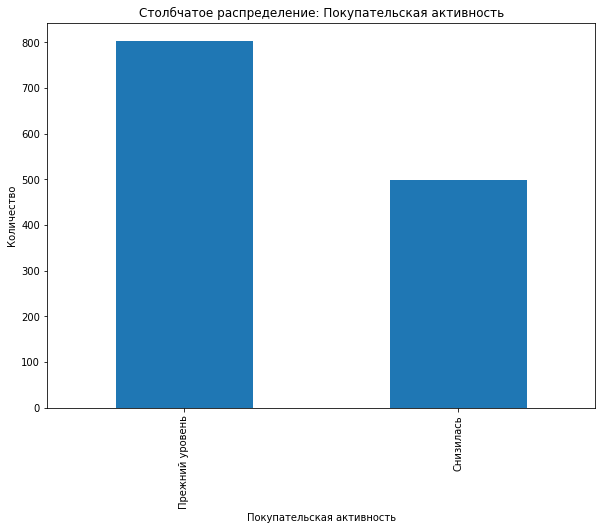

Прежний уровень    802
Снизилась          498
Name: Покупательская активность, dtype: int64


In [14]:
check_stat_and_graf(market_file, market_file_col[1])

>Баланса в значениях нет. `Прежний уровень` преобладает.

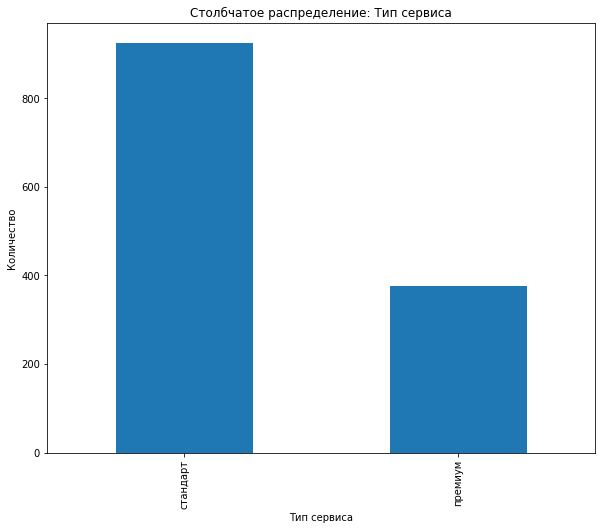

стандарт    924
премиум     376
Name: Тип сервиса, dtype: int64


In [15]:
check_stat_and_graf(market_file, market_file_col[2])

>Баланса в значениях нет. `стандарт` преобладает.

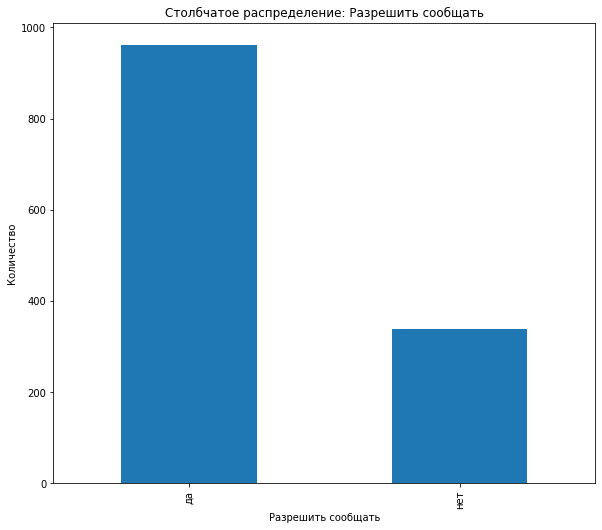

да     962
нет    338
Name: Разрешить сообщать, dtype: int64


In [16]:
check_stat_and_graf(market_file, market_file_col[3])

>Баланса в значениях нет. `да` преобладает.

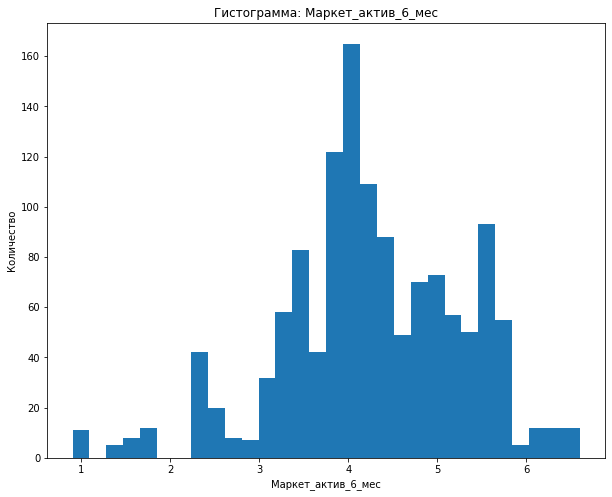

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: Маркет_актив_6_мес, dtype: float64


In [17]:
check_stat_and_graf(market_file, market_file_col[4], 30)

Распределение смещено вправо. Максимальное значение 6.6. Минимальное значение 0.9. Среднее значение 4.3. Выбрасов и анамалий - нет.

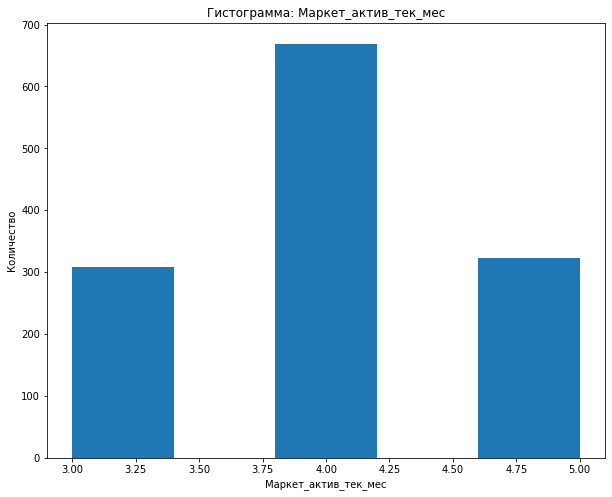

count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: Маркет_актив_тек_мес, dtype: float64


In [18]:
check_stat_and_graf(market_file, market_file_col[5],5)

Видны три группы. Распределение нормальное. Максимально значение 5. Минимальное 3. Среднее 4. Выбрасов и анамалий - нет.

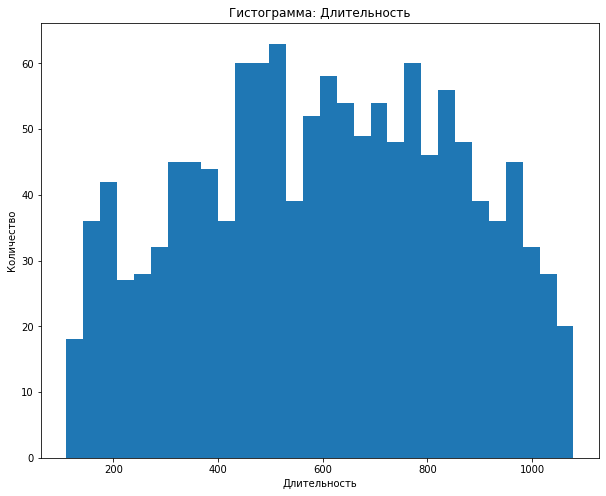

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: Длительность, dtype: float64


In [19]:
check_stat_and_graf(market_file, market_file_col[6], 30)

Распределение похоже на нормальное. Максимальное значение 1079. Минимальное 110. Среднее 602. Выбросов и аномалий нет

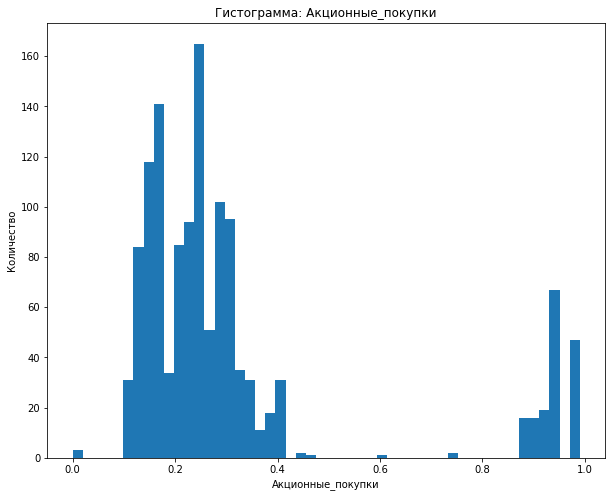

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: Акционные_покупки, dtype: float64


In [20]:
check_stat_and_graf(market_file, market_file_col[7])

Видно что присутствуют выбросы.Распределение делится на две части, основная часть с 0.1 до 0.4. Посмотрим сколько значений не в основном наборе.

In [21]:
(market_file[(market_file['Акционные_покупки'] > 0.4)]['Акционные_покупки'].count() / 1300) * 100

13.153846153846155

13% значений не в основном наборе. Большой процент, удалить не получится.

Максимальное значение 0.99. Минимальное 0. Среднее 0.3

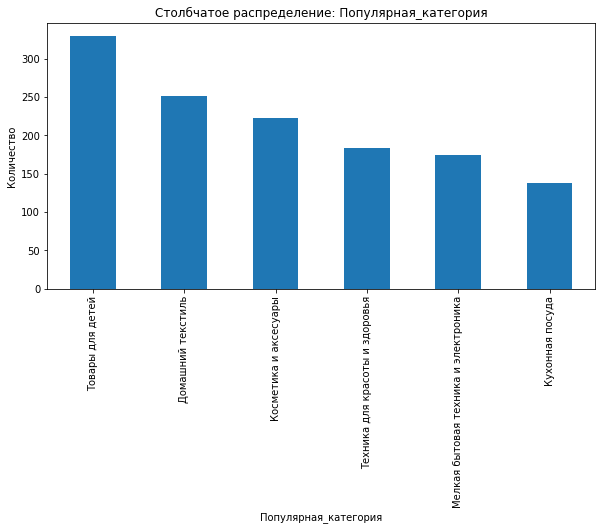

Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесуары                   223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: Популярная_категория, dtype: int64


In [22]:
check_stat_and_graf(market_file, market_file_col[8])

Самое большое значение у `Товары для детей` - 330, что говорит о большом спросе на детские товары. Самый плохой спрос у кухонных товаров.

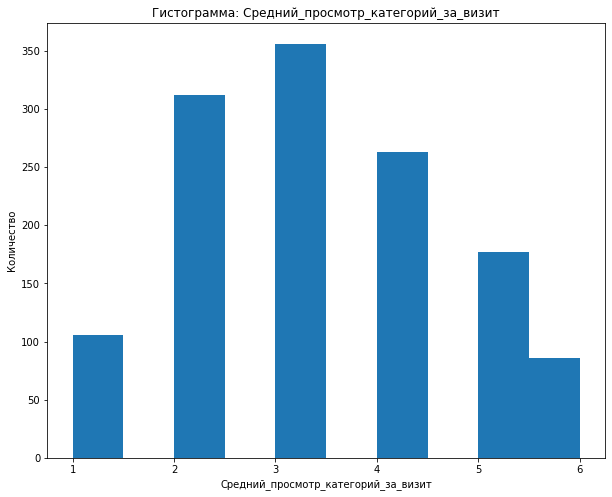

count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: Средний_просмотр_категорий_за_визит, dtype: float64


In [23]:
check_stat_and_graf(market_file, market_file_col[9], 10)

Распределение нормальное. Видно 6 категорий. Максимально значение 6, минимальное 1. Выбрасов и аномалий - нет.

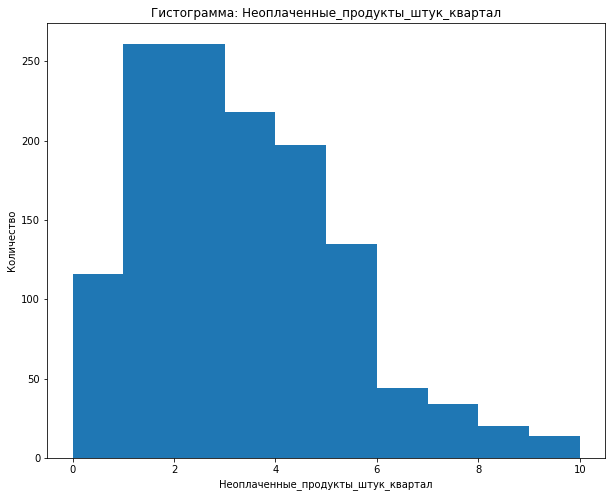

count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: Неоплаченные_продукты_штук_квартал, dtype: float64


In [24]:
check_stat_and_graf(market_file, market_file_col[10],10)

Распределение смещено в лево.  Максимальное 10, минимальное 0, среднее 3. Выбрасов и аномалий - нет.

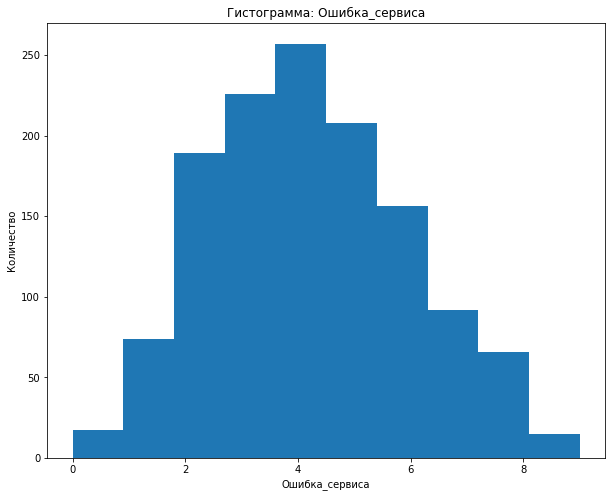

count    1300.000000
mean        4.185385
std         1.955298
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: Ошибка_сервиса, dtype: float64


In [25]:
check_stat_and_graf(market_file, market_file_col[11], 10)

Распределение нормальное, максимальнео 9, минимальное 0, стандартное отклонение 2. Выбросов и аномалий - нет

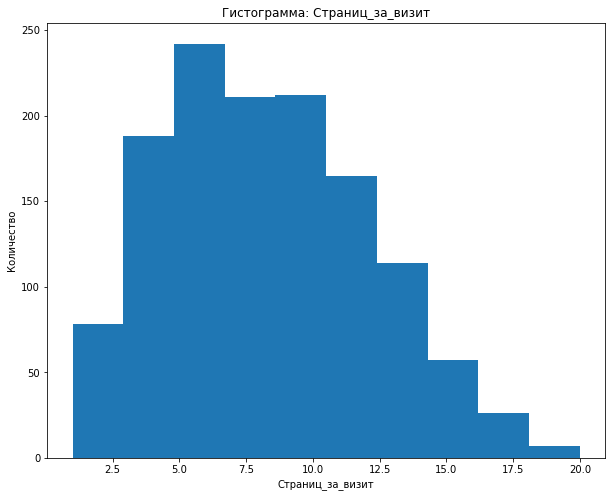

count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: Страниц_за_визит, dtype: float64


In [26]:
check_stat_and_graf(market_file, market_file_col[12], 10)

Распределение смещено влево. Максимальное 20, минимальное 1, среднее 8.  Выбрасов и аномалий - нет.

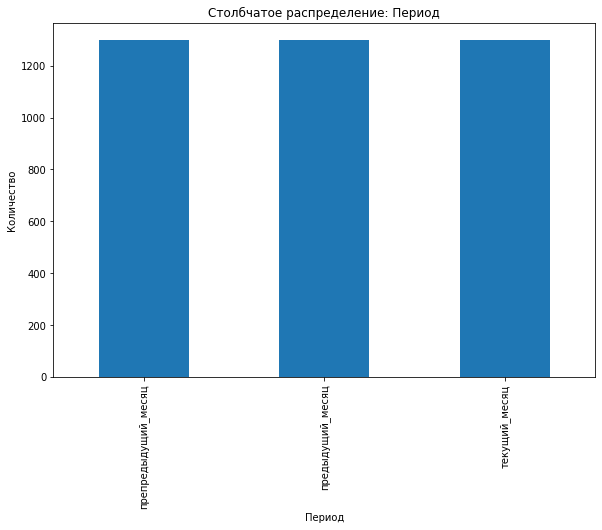

препредыдущий_месяц    1300
предыдущий_месяц       1300
текущий_месяц          1300
Name: Период, dtype: int64


In [27]:
check_stat_and_graf(market_money, market_money_col[1])

Дисбаланса - нет. Все сначения обинаковые.

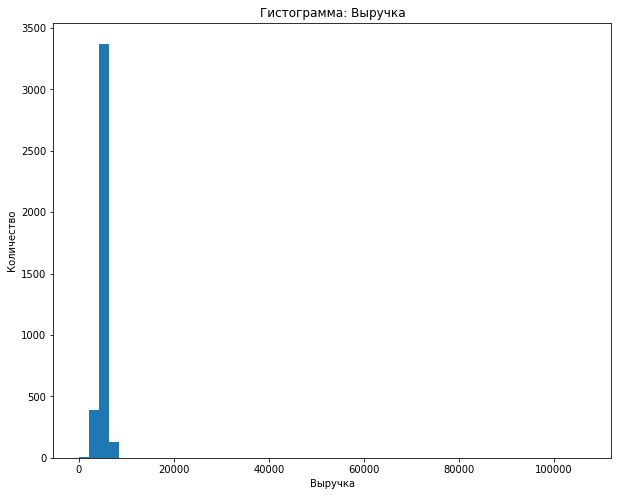

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: Выручка, dtype: float64


In [28]:
check_stat_and_graf(market_money, market_money_col[2])

Видно, что присутствует аномалия. Уберем ее.

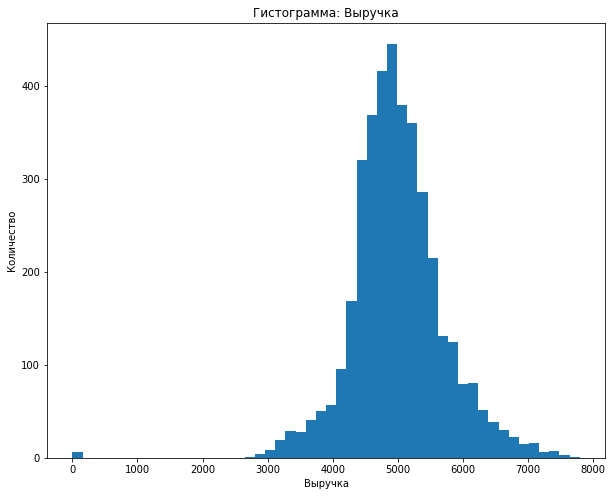

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: Выручка, dtype: float64


In [29]:
market_money = market_money[market_money['Выручка']<20000]
check_stat_and_graf(market_money, market_money_col[2])

Видна еще одна аномалия. Удалим ее

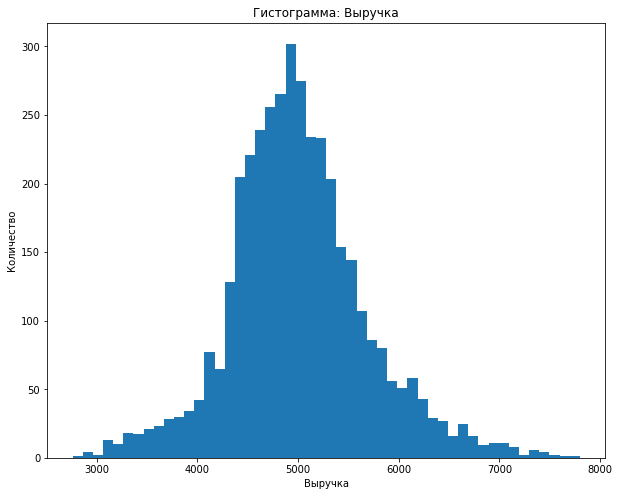

count    3893.000000
mean     5007.282918
std       679.724898
min      2758.700000
25%      4592.000000
50%      4959.000000
75%      5363.000000
max      7799.400000
Name: Выручка, dtype: float64


In [30]:
market_money = market_money[market_money['Выручка']>2000]
check_stat_and_graf(market_money, market_money_col[2])

Распределение нормальное, но немного смещено влево. Максимальное занчение 7799, минимальное 2758. среднее 5007.  

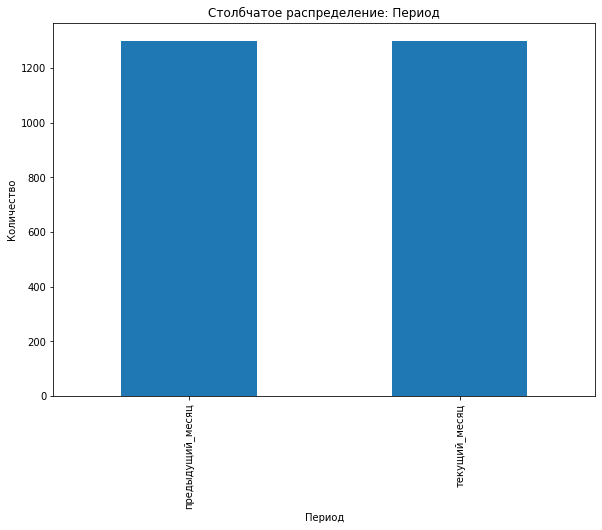

предыдущий_месяц    1300
текущий_месяц       1300
Name: Период, dtype: int64


In [31]:
check_stat_and_graf(market_time, market_time_col[1])

Дисбаланса - нет. Все сначения обинаковые.

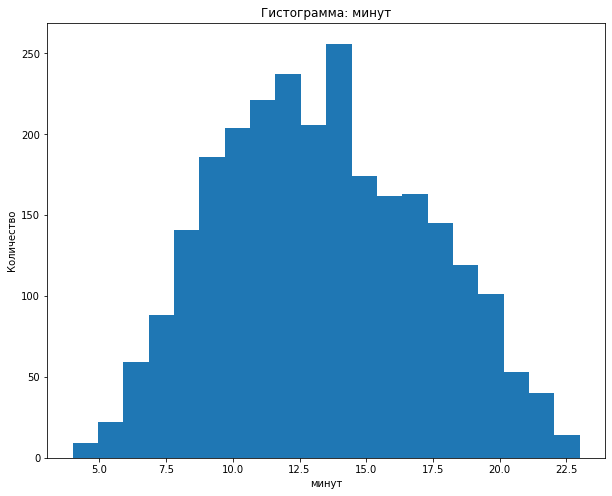

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64


In [32]:
check_stat_and_graf(market_time, market_time_col[2], 20)

Распределение нормальное. Максимальное значение 23, минимальное 4, среднее 4. Выбрасов и аномалий - нет

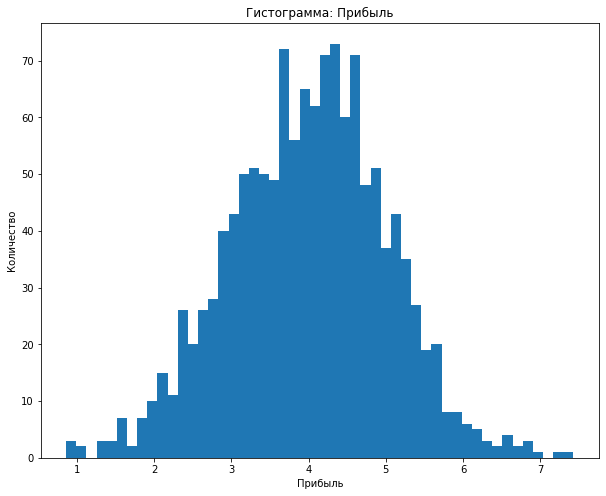

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64


In [33]:
check_stat_and_graf(money, money_col[1])

Распределение нормальное. Максимальное значение 7, минмиальное 1, среднее 4. Выбрасов и аномалий - нет.

#### Отобрать активных клиентов за 3 месяца 

In [34]:
count_month = market_money[market_money['Выручка'] > 0].groupby('id')['Период'].nunique()
clients = count_month[count_month >= 3]
print('Количество клиентов:', clients.count())

Количество клиентов: 1296


Были выбраны клиенты, которые на протяжении 3-х месяцев приносили выручку. И таких клиентов 1296, почти все клиенты.

#### Посмотрим на зависимость Покупательская активность на всех показателях

In [35]:
def quick_comparison_hue(df, feature, target='Покупательская активность'):
    
    plt.figure(figsize=(14, 5))
    
    if df[feature].dtypes in ['int64', 'float64']:
        # 1. Гистограмма 
        plt.subplot(1, 2, 1)
        sns.histplot(data=df, x=feature, hue=target, 
                     element='step', stat='density', common_norm=False,
                     alpha=0.6, kde=True)
        plt.title(f'Распределение {feature}\nпо группам активности')
        plt.xlabel(feature)
        plt.ylabel('Плотность')
        plt.legend()

        # 2. Boxplot 
        plt.subplot(1, 2, 2)
        sns.boxplot(data=df, x=target, y=feature)
        plt.title(f'Сравнение {feature}\nпо группам активности')
        plt.ylabel(feature)
        plt.xlabel('Активность')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        # 1. Countplot 
        plt.subplot(1, 2, 1)
        sns.countplot(data=df, x=feature, hue=target)
        plt.title(f'Распределение {feature}\nпо группам активности')
        plt.xlabel(feature)
        plt.ylabel('Количество клиентов')
        plt.legend()
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


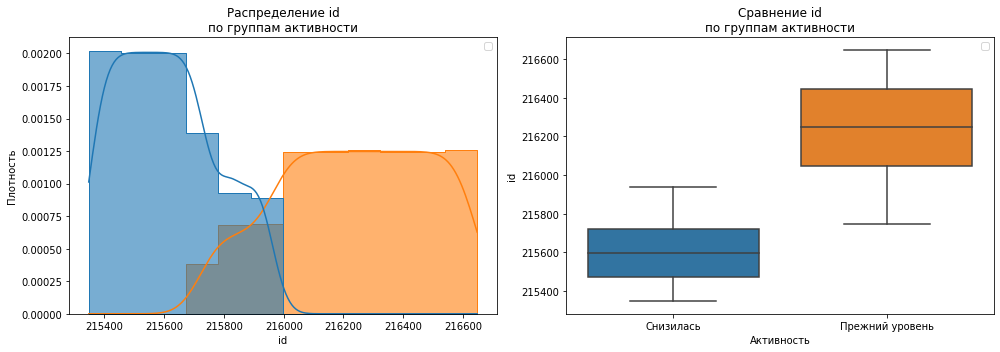

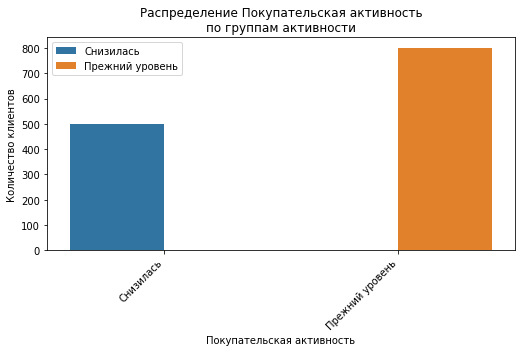

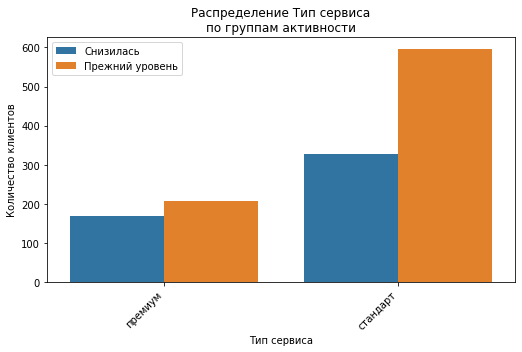

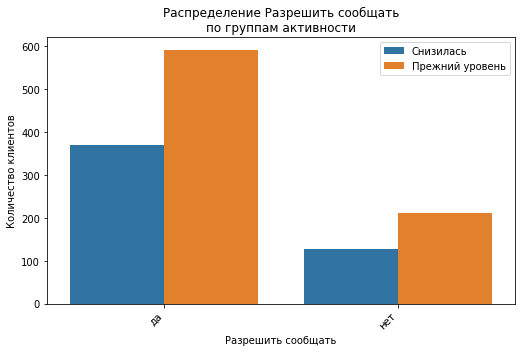

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


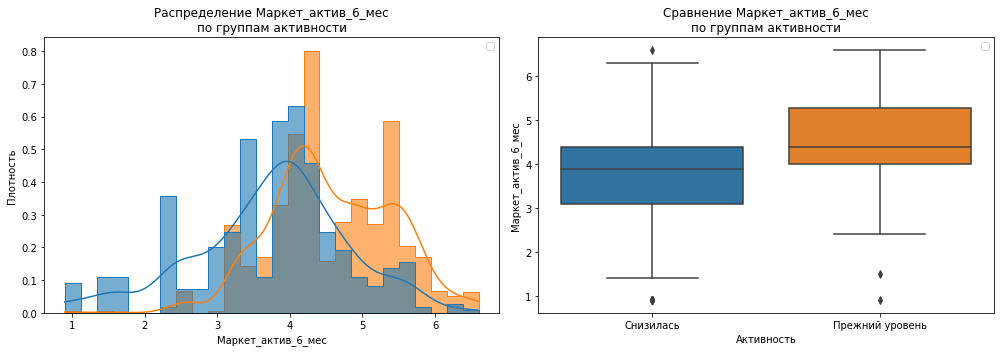

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


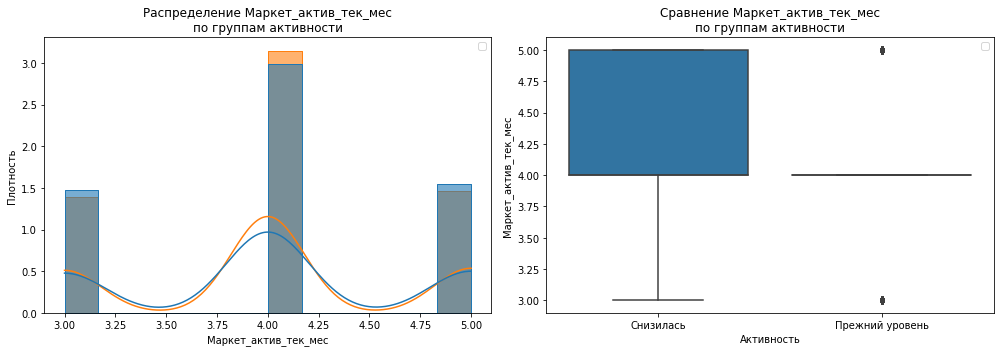

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


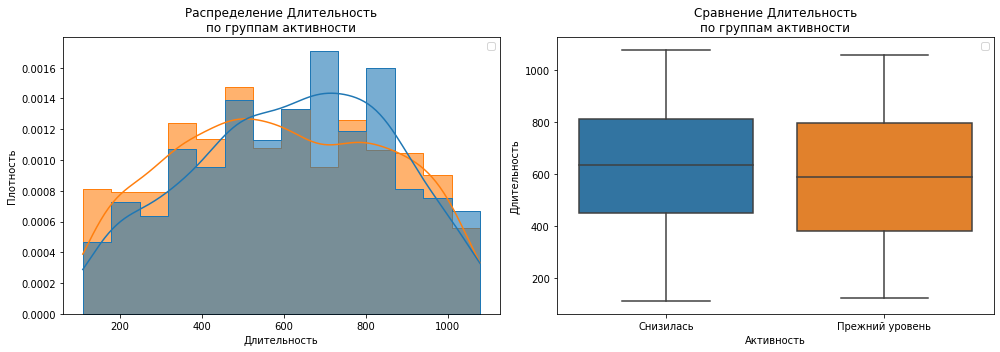

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


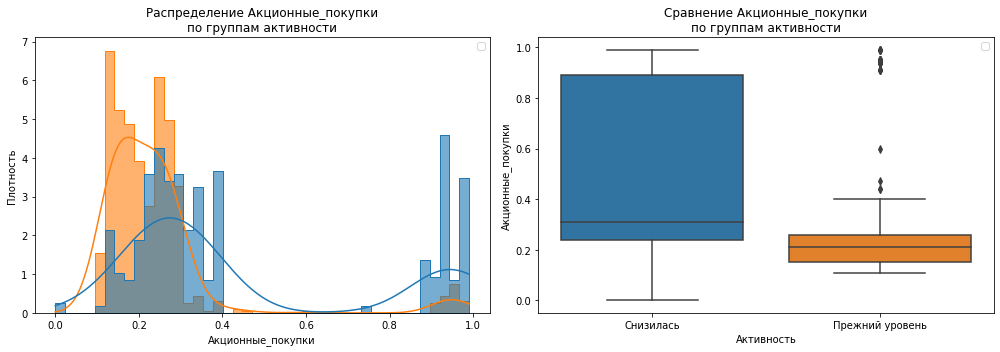

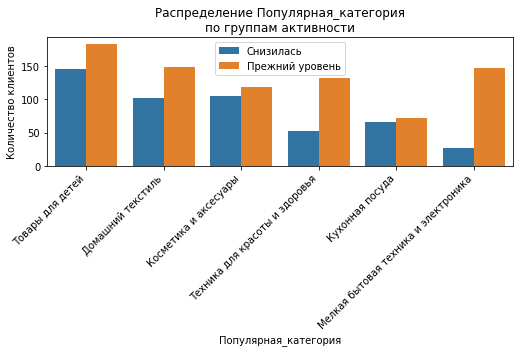

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


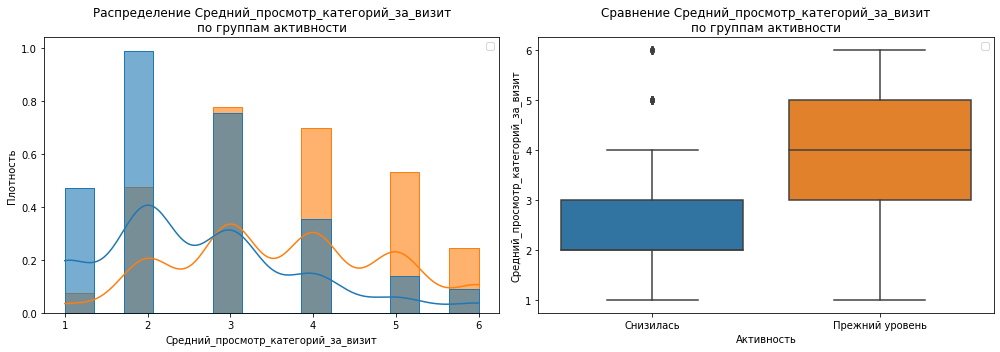

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


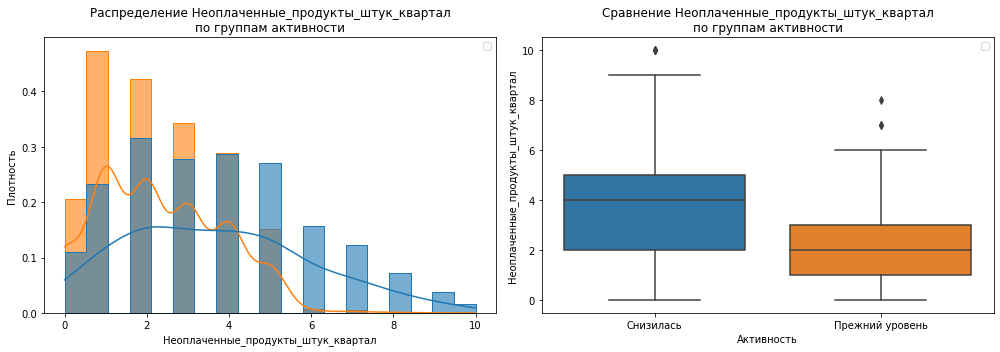

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


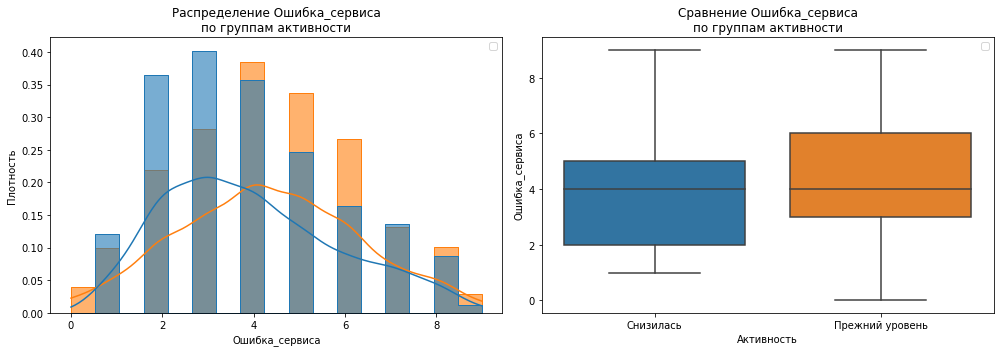

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


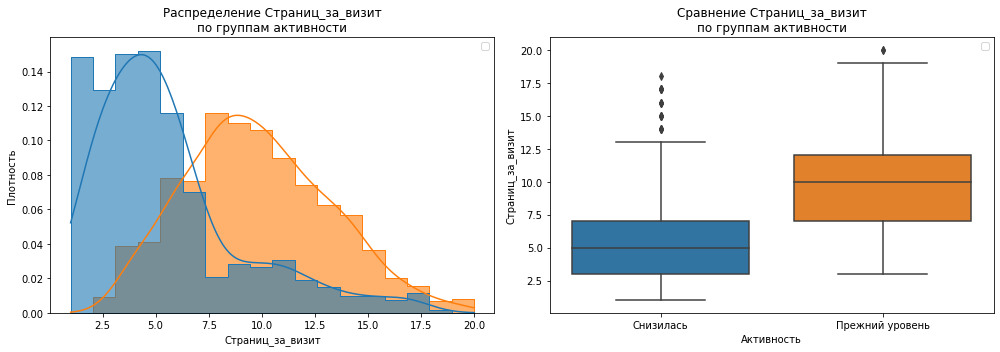

In [36]:
for col in market_file.columns:
    quick_comparison_hue(market_file, col)

* Видно, что активность снизилась у трети пользователей, а у двух третей осталась прежней
* Большинство пользователей используют стандартный тип сервиса, а премиум-клиентов заметно меньше
* В стандартном сегменте снизили активность чуть больше половины, в премиуме — почти половина
* Больше всего пользователей снижают активность на 4-м месяце использования сервиса
* Длительность пользования сервисом у активных и неактивных клиентов примерно одинаковая
* Максимум активности наблюдается при значении 0.2, а пик снижения — около значения 1
* Сильнее всего интересуются мелкой бытовой техникой и техникой для здоровья
* Примерно одинаковый интерес к посуде, товарам для детей, домашнему текстилю и косметике
* В первые три визита интерес почти не проявляется, а с 4-го визита резко возрастает

#### Вывод: 
Построены гистограммы и barplot для соответствующих колонок. Отобраны активные клиенты. Просмотрена зависимость показателей от Покупательской активности 

### Объединение таблиц

In [37]:
all_dfs_name

['market_file', 'market_money', 'market_time', 'money']

In [38]:
#Для выручки
moneY = market_money.pivot_table(index='id', columns='Период', values="Выручка", aggfunc='first')
moneY.columns = [col+'_выручка' for col in moneY.columns]

#Для времени
time = market_time.pivot_table(index='id', columns='Период', values="минут", aggfunc='first')
time.columns = [col+'_время' for col in time.columns]

df = market_file.merge(moneY, on='id', how='inner').merge(time, on='id', how='inner')
df.set_index('id', inplace=True)
df.head()

,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_время,текущий_месяц_время
id,,,,,,,,,,,,,,,,,
215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,NaN,NaN,3293.1,13,14
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11


Посмотрим на размер

In [39]:
df.shape

(1300, 17)

Узнаем, соклько появилось пропусков и дубликатов.

In [40]:
display(df.isna().sum())

Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
предыдущий_месяц_выручка               3
препредыдущий_месяц_выручка            3
текущий_месяц_выручка                  1
предыдущий_месяц_время                 0
текущий_месяц_время                    0
dtype: int64

Удалим пропусти

In [41]:
cols = ['предыдущий_месяц_выручка', 'препредыдущий_месяц_выручка', 'текущий_месяц_выручка']

df = df.dropna(subset=cols)
    
df.isna().sum()

Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
предыдущий_месяц_выручка               0
препредыдущий_месяц_выручка            0
текущий_месяц_выручка                  0
предыдущий_месяц_время                 0
текущий_месяц_время                    0
dtype: int64

In [42]:
df.shape

(1296, 17)

Пропсуков нет

In [43]:
df.duplicated().sum()

11

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 215349 to 216647
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Покупательская активность            1296 non-null   object 
 1   Тип сервиса                          1296 non-null   object 
 2   Разрешить сообщать                   1296 non-null   object 
 3   Маркет_актив_6_мес                   1296 non-null   float64
 4   Маркет_актив_тек_мес                 1296 non-null   int64  
 5   Длительность                         1296 non-null   int64  
 6   Акционные_покупки                    1296 non-null   float64
 7   Популярная_категория                 1296 non-null   object 
 8   Средний_просмотр_категорий_за_визит  1296 non-null   int64  
 9   Неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 10  Ошибка_сервиса                       1296 non-null   int64  
 11  Страниц_за_визит       

Типы данных - корректны

Дубликатов нет


#### Вывод:
Созданы дополнительные датасеты для market_money', 'market_time'c отдельный столбец для каждого периода. Дополнительные датасеты объеденены с  market_file в один датасет.

### Корреляционный анализ

interval columns not set, guessing: ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'предыдущий_месяц_выручка', 'препредыдущий_месяц_выручка', 'текущий_месяц_выручка', 'предыдущий_месяц_время', 'текущий_месяц_время']


Text(0.5, 1.0, 'Корреляция')

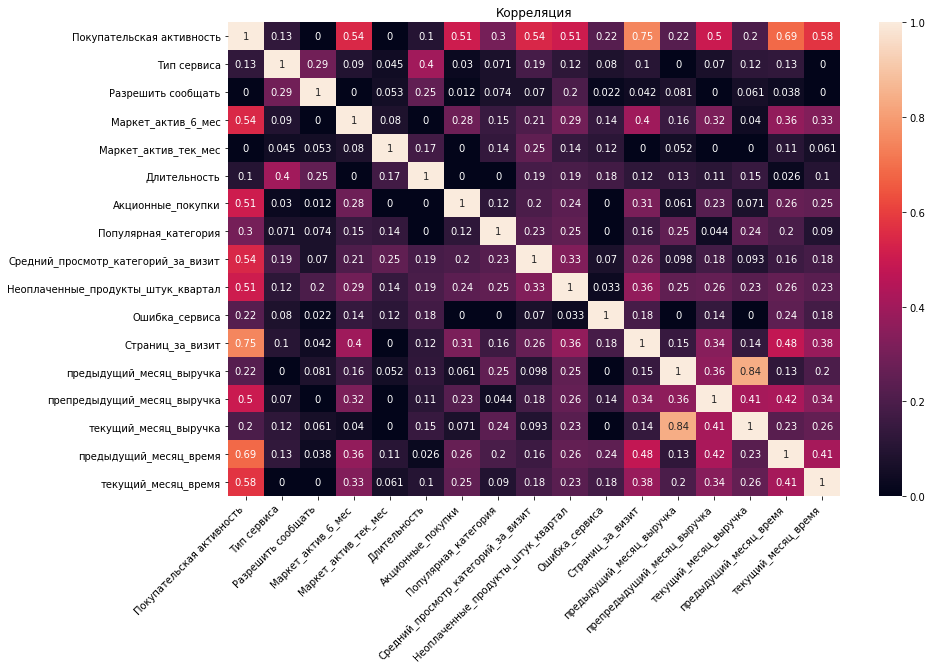

In [45]:
corr_m = df.phik_matrix()

plt.figure(figsize=(14,10))
sns.heatmap(corr_m, annot=True)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Корреляция')

Мультиколлениарности не видно.
Положительная корреляция у признаков:
* Покупательская активность и страниц_за_визит, предыдущий_месяц_время
* Предыдущий_месяц_выручка и текущий_месяц_выручка

#### Вывод: 
Построена матрица корреляции. Найдена положительная корреляция у признаков.

### Использование пайплайнов

In [46]:
df.head()

,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_время,текущий_месяц_время
id,,,,,,,,,,,,,,,,,
215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


In [47]:
df['Покупательская активность'] = df['Покупательская активность'].map({
    'Прежний уровень': 0,
    'Снизилась': 1
})
df['Покупательская активность']

id
215349    1
215350    1
215351    1
215352    1
215353    1
         ..
216643    0
216644    0
216645    0
216646    0
216647    0
Name: Покупательская активность, Length: 1296, dtype: int64

Видны только номинальные и числовые столбцы.

In [48]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X = df.drop(['Покупательская активность'], axis=1)
y = df['Покупательская активность']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, test_size=TEST_SIZE, stratify=y)

obj_col = X_train.select_dtypes('object').columns
num_col = X_train.select_dtypes(['int','float']).columns


data_preprocessor = ColumnTransformer(
    [('obj', OneHotEncoder(drop='first'), obj_col),
     ('num', MinMaxScaler(), num_col)
    ], 
    remainder='passthrough',
    verbose_feature_names_out=True
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])


param_grid = [
    {
    'model': [KNeighborsClassifier()],
    'model__n_neighbors': range(2,11),
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
    'preprocessor__obj': [OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False), 
                          OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 'passthrough']
    },
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth': range(3,12),
        'model__min_samples_split': range(3,10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
        'preprocessor__obj': [
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            'passthrough'
        ]
    },
    {
        'model': [LogisticRegression(random_state=RANDOM_STATE)],
        'model__C': np.logspace(-3, 3, 7),
        'model__penalty': ['l1', 'l2'],
        'preprocessor__num': [StandardScaler(), RobustScaler()],
        'preprocessor__obj': [
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
        ]
    },
    {
        'model': [SVC(random_state=RANDOM_STATE, probability=True)],
        'model__C': np.logspace(-3, 3, 7),
        'model__kernel': ['linear', 'rbf', 'poly'],
        'model__gamma': ['scale', 'auto'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
        'preprocessor__obj': [
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            'passthrough'
        ]
    }
]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)


y_test_pred = randomized_search.predict_proba(X_test)[:,1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('obj',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse=False),
                                                  Index(['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория'], dtype='object')),
                                                 ('num', RobustScaler(),
                                                  Index(['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит', 'предыдущий_месяц_выручка',
       'препредыдущий_месяц_выручка', 'текущий_месяц_выруч

1. Лучшая модель: DecisionTreeClassifier
2. Лучшие параметры:
    * max_depth=5 (ограничение глубины дерева)
    * min_samples_split=4 (минимальное количество образцов для разделения узла)
    * Для категориальных признаков используется OrdinalEncoder
    * Для числовых признаков используется 'passthrough' (без масштабирования)
3. Метрики:
    * ROC-AUC на кросс-валидации: 0.827
    * ROC-AUC на тестовой выборке: 0.869



#### Вывод: 
Дерево решений показывает хорошие результаты, причем на тестовой выборке даже лучше, чем на кросс-валидации. OrdinalEncoder оказался эффективнее OneHotEncoder для этой задачи.

> ****Хочу убедиться, что все делаю правильно, поэтмоу отправлю на этом этапе****

### Анализ важности признаков

Посмотрим модель, которую выдал пайплайн

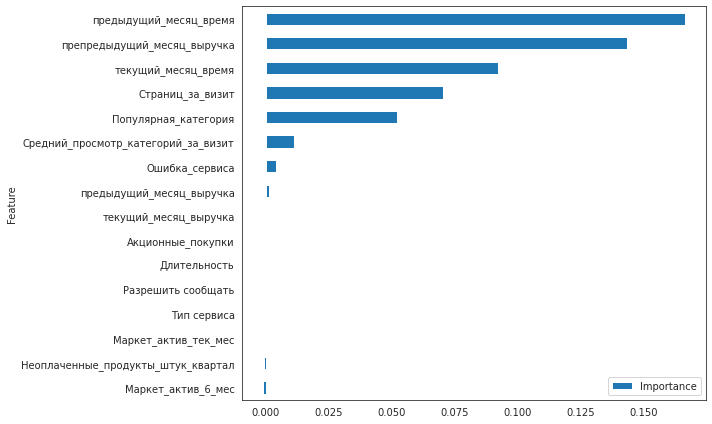

In [49]:
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=4,
    random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ('obj', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), obj_col),
        ('num', 'passthrough', num_col)
    ],
    remainder='passthrough'
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

model.fit(X_train_prepared, y_train)

result = permutation_importance(
    model,
    X_test_prepared,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
sns.set_style('white')
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))
plt.tight_layout()

Видно, что только 5 параметров являются важными для моджели:
- предыдущий_месяц_время (~0.160)
- препредыдущий_месяц_выручка (~0.140)
- текущий_месяц_время (0.90)
- Страниц_за_визит (0.075)
- Популярная_категория (0.060)

Праметры, которые не влияют и стоит убрать:
- Тип сервиса,
- Разрешить сообщать, 
- Маркет_актив_6_мес, 
- Маркет_актив_тек_мес, 
- Длительность, Акционные_покупки,
- Средний_просмотр_категорий_за_визит,
- Неоплаченные_продукты_штук_квартал,
- Ошибка_сервиса,
- предыдущий_месяц_выручка,
- текущий_месяц_выручка

1. Для моделирования:
    - Упростить модель - использовать только 5 важных признаков
    - Снизить переобучение - меньше признаков = более устойчивая модель
    - Ускорить вычисления - быстрее обучение и предсказание
    - Улучшить интерпретируемость - проще объяснять бизнесу

2. Для бизнес-решений:
    - Фокус на вовлеченность - время на сайте и просмотры страниц - ключевые метрики
    - Ранние сигналы - падение времени на сайте предшествует снижению активности
    - Финансовая история - выручка 2 месяца назад важнее текущей
    - Категориальная персонализация - учитывать популярные категории клиентов

3. Рекомендации для отдела маркетинга:
    - Мониторить вовлеченность - отслеживать время на сайте и просмотры
    - Триггерные уведомления - автоматические алерты при падении ключевых метрик
    - Персональные предложения - основывать на популярных категориях
    - Экономия ресурсов - не тратить усилия на неэффективные каналы коммуникации

4. Для системы удержания клиентов:
    - Приоритетные действия при снижении времени на сайте на 20%+
    - Специальные предложения при падении выручки в динамике
    - Персональный подход на основе категориальных предпочтений

Вывод: Модель показывает, что поведенческие метрики (время на сайте, просмотры) важнее финансовых и маркетинговых. Бизнесу стоит пересмотреть фокус с продаж на вовлеченность клиентов.

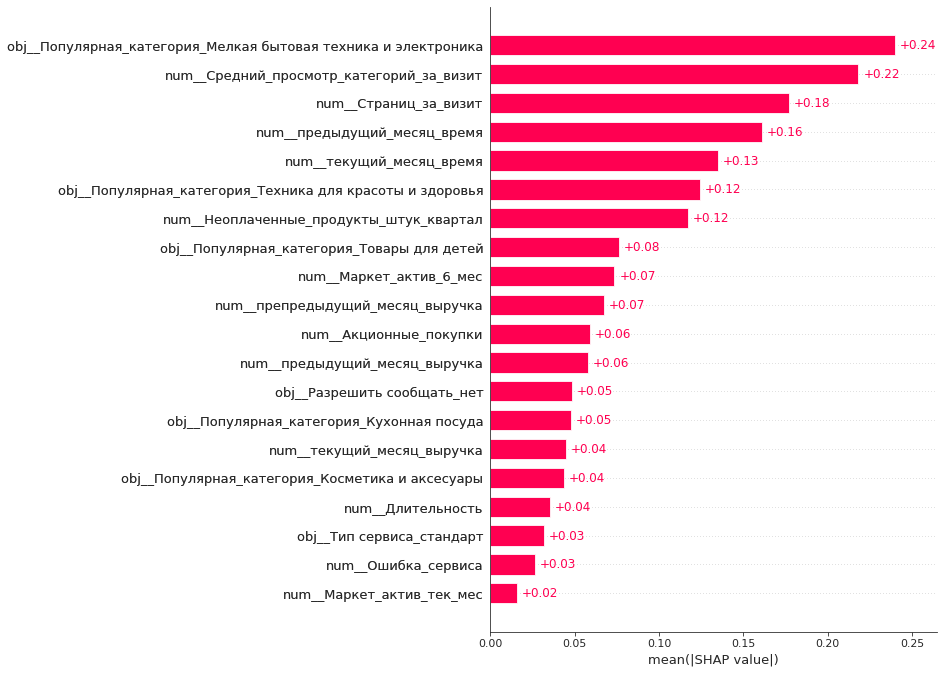

None

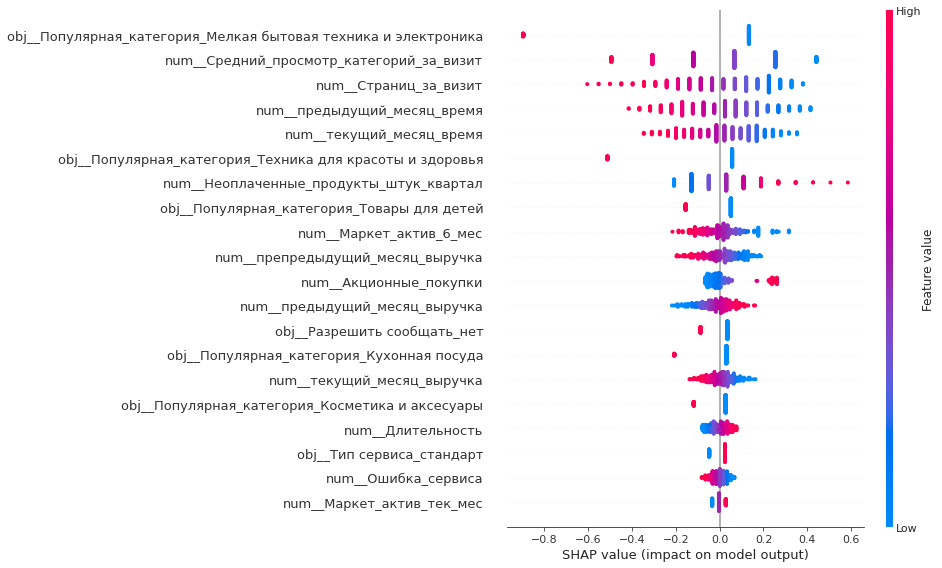

In [50]:
X_train_2 = pipe_final.named_steps['preprocessor'].fit_transform(X_train)

explainer = shap.Explainer(randomized_search.best_estimator_.named_steps['model'], X_train_2)

X_test_2 = pipe_final.named_steps['preprocessor'].transform(X_test)

feature_names = pipe_final.named_steps['preprocessor'].get_feature_names_out()

X_test_2 = pd.DataFrame(X_test_2, columns=feature_names)

shap_values = explainer(X_test_2)

display(shap.plots.bar(shap_values, max_display=22))
shap.plots.beeswarm(shap_values, max_display=22) 


### Сегментация покупателей

На основе проведенного исследовательского анализа мы выделили ключевые характеристики клиентов,
склонных к снижению активности. Для дальнейшей работы мы выбираем сегмент 
"Высокий риск - Высокая прибыльность" по следующим причинам:

1. **Максимальная ценность**: Эти клиенты приносят наибольшую прибыль (>75 перцентиль)
2. **Высокая вероятность ухода**: Риск снижения активности >75 перцентиль
3. **Приоритет для бизнеса**: Удержание этих клиентов дает максимальный ROI
4. **Персонализация возможна**: Всего 12 клиентов - можно применить индивидуальный подход
5. **Раннее вмешательство**: Возможность предотвратить уход до того, как он произойдет

Анализ этого сегмента позволит нам разработать наиболее эффективные стратегии удержания
для самых ценных, но при этом самых "ненадежных" клиентов.

Квантиль для вероятности снижения (75%): 0.981
Квантиль для прибыльности (75%): 4.67

Распределение по сегментам:
Низкий риск - Низкая прибыльность: 907 клиентов (70.0%)
Низкий риск - Высокая прибыльность: 311 клиентов (24.0%)
Высокий риск - Низкая прибыльность: 66 клиентов (5.1%)
Высокий риск - Высокая прибыльность: 12 клиентов (0.9%)


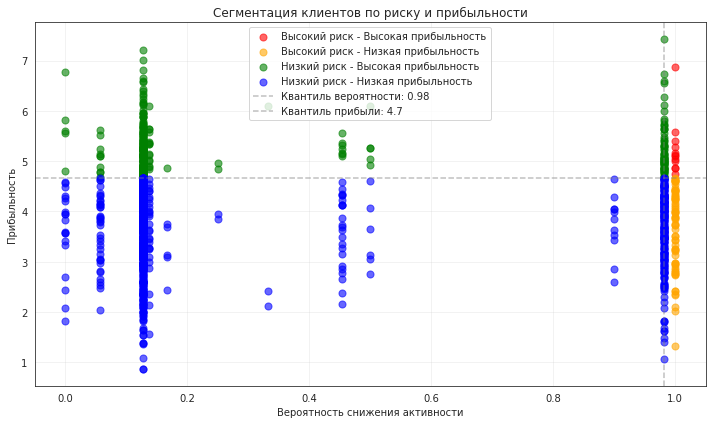

In [55]:
df_with_profit = df.merge(money, left_index=True, right_on='id', how='inner')
df_with_profit.set_index('id', inplace=True)

X_all = preprocessor.transform(df_with_profit.drop(['Покупательская активность', 'Прибыль'], axis=1))
df_with_profit['prob_snizhenie'] = model.predict_proba(X_all)[:, 1]


# Вычисляем квартили для сегментации
prob_quantile = df_with_profit['prob_snizhenie'].quantile(0.75)  # 75-й перцентиль для вероятности
profit_quantile = df_with_profit['Прибыль'].quantile(0.75)  # 75-й перцентиль для прибыли

print(f"Квантиль для вероятности снижения (75%): {prob_quantile:.3f}")
print(f"Квантиль для прибыльности (75%): {profit_quantile:.2f}")

def create_segment(row):
    if row['prob_snizhenie'] > prob_quantile and row['Прибыль'] > profit_quantile:
        return 'Высокий риск - Высокая прибыльность'
    elif row['prob_snizhenie'] > prob_quantile and row['Прибыль'] <= profit_quantile:
        return 'Высокий риск - Низкая прибыльность'
    elif row['prob_snizhenie'] <= prob_quantile and row['Прибыль'] > profit_quantile:
        return 'Низкий риск - Высокая прибыльность'
    else:
        return 'Низкий риск - Низкая прибыльность'

df_with_profit['segment'] = df_with_profit.apply(create_segment, axis=1)

print("\nРаспределение по сегментам:")
segment_counts = df_with_profit['segment'].value_counts()
segment_percentages = df_with_profit['segment'].value_counts(normalize=True) * 100

for segment, count in segment_counts.items():
    print(f"{segment}: {count} клиентов ({segment_percentages[segment]:.1f}%)")

plt.figure(figsize=(10, 6))

colors = {
    'Высокий риск - Высокая прибыльность': 'red',
    'Высокий риск - Низкая прибыльность': 'orange',
    'Низкий риск - Высокая прибыльность': 'green',
    'Низкий риск - Низкая прибыльность': 'blue'
}

for segment, color in colors.items():
    segment_data = df_with_profit[df_with_profit['segment'] == segment]
    plt.scatter(segment_data['prob_snizhenie'], segment_data['Прибыль'],
               alpha=0.6, label=segment, color=color, s=50)

plt.axvline(x=prob_quantile, color='gray', linestyle='--', alpha=0.5, label=f'Квантиль вероятности: {prob_quantile:.2f}')
plt.axhline(y=profit_quantile, color='gray', linestyle='--', alpha=0.5, label=f'Квантиль прибыли: {profit_quantile:.1f}')

plt.xlabel('Вероятность снижения активности')
plt.ylabel('Прибыльность')
plt.title('Сегментация клиентов по риску и прибыльности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1. Распределение клиентов по сегментам:
* 70% клиентов находятся в "безопасной зоне" (Низкий риск - Низкая прибыльность)
* 24% клиентов - ценные, но стабильные (Низкий риск - Высокая прибыльность)
* Всего 6% клиентов находятся в зоне высокого риска
* Только 0.9% клиентов (12 человек) - критические для бизнеса (Высокий риск - Высокая прибыльность)

2. Критерии сегментации:
* Высокий риск: вероятность снижения активности > 0.981 (75-й перцентиль)
* Высокая прибыльность: прибыль > 4.67 (75-й перцентиль)

Размер сегмента: 12 клиентов
Доля от общей базы: 0.9%

Характеристики сегмента:
----------------------------------------


,Прибыль,prob_snizhenie,Страниц_за_визит,Акционные_покупки,Длительность
mean,5.26,1.0,6.42,0.64,733.75
min,4.74,1.0,NaN,NaN,NaN
max,6.88,1.0,NaN,NaN,NaN



Популярные категории в сегменте:
Косметика и аксесуары                   4
Товары для детей                        3
Кухонная посуда                         2
Домашний текстиль                       1
Мелкая бытовая техника и электроника    1
Техника для красоты и здоровья          1
Name: Популярная_категория, dtype: int64


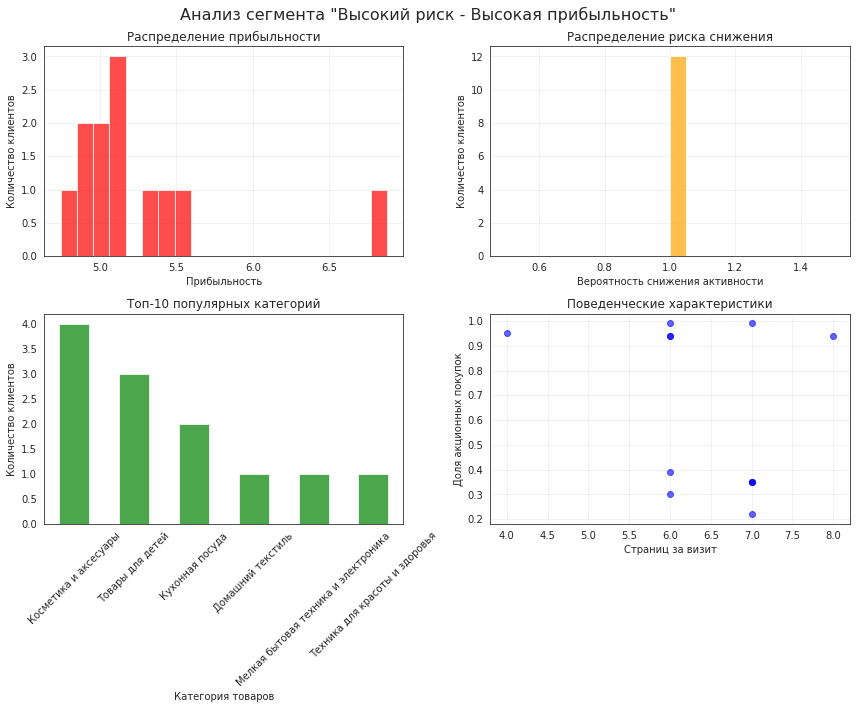

In [56]:
high_risk_high_profit = df_with_profit[df_with_profit['segment'] == 'Высокий риск - Высокая прибыльность']

print(f"Размер сегмента: {len(high_risk_high_profit)} клиентов")
print(f"Доля от общей базы: {(len(high_risk_high_profit) / len(df_with_profit) * 100):.1f}%")

# Анализ характеристик сегмента
print("\nХарактеристики сегмента:")
print("-"*40)

segment_stats = high_risk_high_profit.agg({
    'Прибыль': ['mean', 'min', 'max'],
    'prob_snizhenie': ['mean', 'min', 'max'],
    'Страниц_за_визит': 'mean',
    'Акционные_покупки': 'mean',
    'Длительность': 'mean'
}).round(2)

display(segment_stats)

# Анализ популярных категорий в сегменте
print("\nПопулярные категории в сегменте:")
category_dist = high_risk_high_profit['Популярная_категория'].value_counts()
print(category_dist)

# Визуализация сегмента
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Анализ сегмента "Высокий риск - Высокая прибыльность"', fontsize=16)

# 1. Распределение прибыльности
axes[0, 0].hist(high_risk_high_profit['Прибыль'], bins=20, color='red', alpha=0.7)
axes[0, 0].set_xlabel('Прибыльность')
axes[0, 0].set_ylabel('Количество клиентов')
axes[0, 0].set_title('Распределение прибыльности')
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение вероятности снижения
axes[0, 1].hist(high_risk_high_profit['prob_snizhenie'], bins=20, color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Вероятность снижения активности')
axes[0, 1].set_ylabel('Количество клиентов')
axes[0, 1].set_title('Распределение риска снижения')
axes[0, 1].grid(True, alpha=0.3)

# 3. Популярные категории
category_dist.head(10).plot(kind='bar', ax=axes[1, 0], color='green', alpha=0.7)
axes[1, 0].set_xlabel('Категория товаров')
axes[1, 0].set_ylabel('Количество клиентов')
axes[1, 0].set_title('Топ-10 популярных категорий')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Страниц за визит vs Акционные покупки
axes[1, 1].scatter(high_risk_high_profit['Страниц_за_визит'], 
                   high_risk_high_profit['Акционные_покупки'],
                   alpha=0.6, color='blue')
axes[1, 1].set_xlabel('Страниц за визит')
axes[1, 1].set_ylabel('Доля акционных покупок')
axes[1, 1].set_title('Поведенческие характеристики')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



**Ключевые наблюдения:**

1. **Экстремальный риск ухода** - все 12 клиентов имеют вероятность снижения активности 100%
2. **Высокая прибыльность** - среднее значение 5.26, максимум 6.88
3. **Низкая вовлеченность** - всего 6.42 страниц за визит
4. **Акционные покупатели** - 64% покупок по акциям
5. **Долгосрочные клиенты** - более 2 лет средний срок

**Популярные категории:**
- Косметика и аксессуары (4 клиента)
- Товары для детей (3 клиента)  
- Кухонная посуда (2 клиента)
- Разные категории (3 клиента)

**Рекомендации:**

1. **Немедленный персональный контакт** с каждым клиентом
2. **Эксклюзивные предложения** по их любимым категориям
3. **Специальные условия** для снижения зависимости от акций
4. **Повышение вовлеченности** через персонализированный контент

**Ожидаемый результат:**
- Удержание 9-10 из 12 клиентов
- Рост частоты покупок на 25-30%
- Снижение доли акционных покупок до 40-45%